# Probability_Distribution_Functions

In [1]:
# Import libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats
plt.rcParams["figure.figsize"]=(8,5)
#This code means by default all the charts will have this size

## Random variable

In [2]:
# Imagine rolling a dice 10,000 times(Discreate variable).
np.random.seed(42)
rolls=np.random.randint(1,7,size=10000)
rolls[:20]

array([4, 5, 3, 5, 5, 2, 3, 3, 3, 5, 4, 3, 6, 5, 2, 4, 6, 6, 2, 4])

In [3]:
np.unique(rolls)

array([1, 2, 3, 4, 5, 6])

In [6]:
# To calculate frequency of each outcome
pd.Series(rolls).value_counts().sort_index()

,count
1,1665
2,1692
3,1625
4,1672
5,1689
6,1657


In [7]:
# converting to probability
probability=pd.Series(rolls).value_counts(normalize=True).sort_index()
probability

,proportion
1,0.1665
2,0.1692
3,0.1625
4,0.1672
5,0.1689
6,0.1657


## PMF - Probability Mass Function

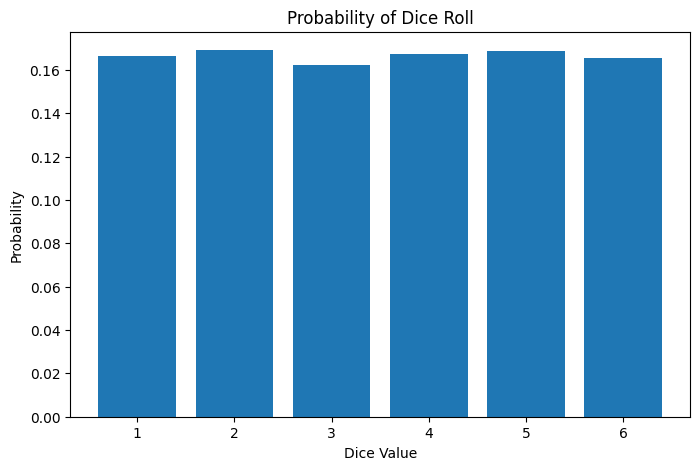

In [8]:
x=probability.index
y=probability.values

plt.bar(x,y)

plt.xlabel("Dice Value")
plt.ylabel("Probability")
plt.title("Probability of Dice Roll")

plt.show()

In [9]:
probability.sum()

np.float64(1.0)

## CDF of PMF

In [10]:
cdf=probability.cumsum()
cdf

,proportion
1,0.1665
2,0.3357
3,0.4982
4,0.6654
5,0.8343
6,1.0000


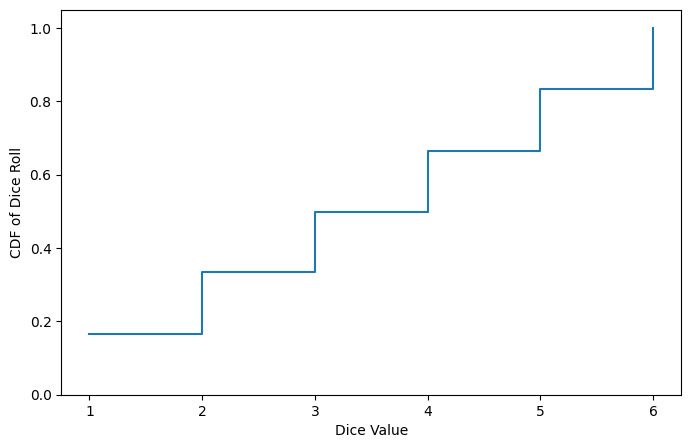

In [12]:
plt.step(cdf.index,cdf.values,where="post")
plt.xlabel("Dice Value")
plt.ylabel("CDF of Dice Roll")

plt.ylim(0,1.05)
plt.show()

In [13]:
cdf.loc[3]

np.float64(0.4982)

## Continous random variable

In [14]:
np.random.seed(42)
data=np.random.normal(loc=50,scale=10,size=10000)
data[:10]

array([54.96714153, 48.61735699, 56.47688538, 65.23029856, 47.65846625,
       47.65863043, 65.79212816, 57.67434729, 45.30525614, 55.42560044])

In [15]:
print("Mean:",data.mean())
print("Standard deviation:",data.std())

Mean: 49.97864016631574
Standard deviation: 10.034122061299875


## Histogram


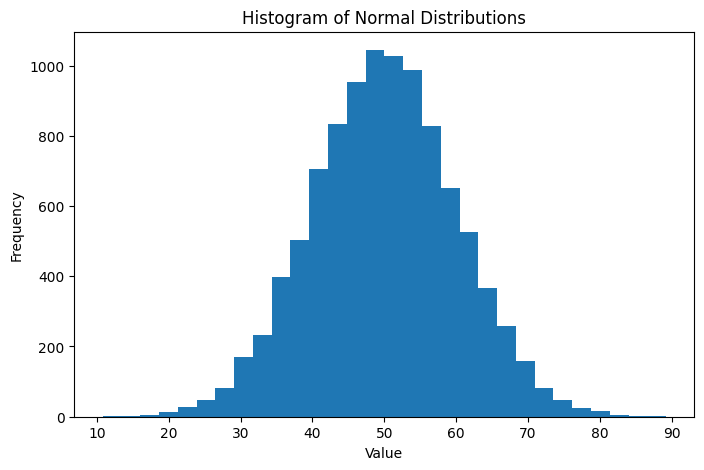

In [17]:
plt.hist(data,bins=30)
plt.xlabel("Value")
plt.ylabel("Frequency")
plt.title("Histogram of Normal Distributions")
plt.show()

## This gives you an estimate of the distribution.

## PDF-Probability Density Function

In [20]:
x=np.linspace(10,90,500)
pdf=stats.norm.pdf(x,loc=50,scale=10)

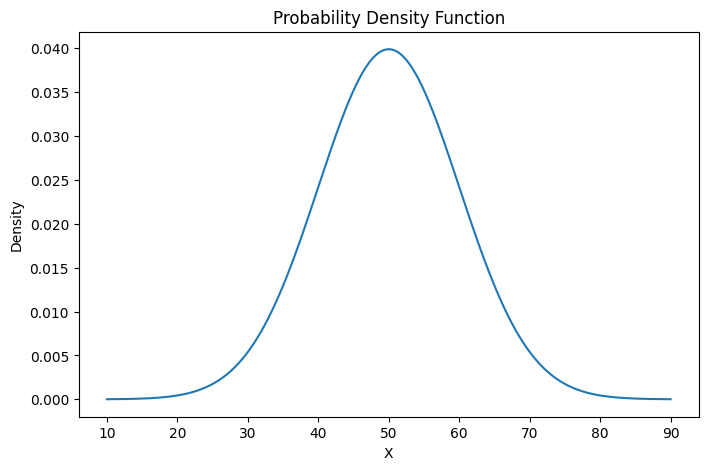

In [21]:
plt.plot(x,pdf)
plt.xlabel("X")
plt.ylabel("Density")
plt.title("Probability Density Function")
plt.show()

## probability using CDF


In [22]:
probability_40_60=(
  stats.norm.cdf(60,loc=50,scale=10)-stats.norm.cdf(40,loc=50,scale=10)
)

probability_40_60

np.float64(0.6826894921370859)

## CDF of PDF


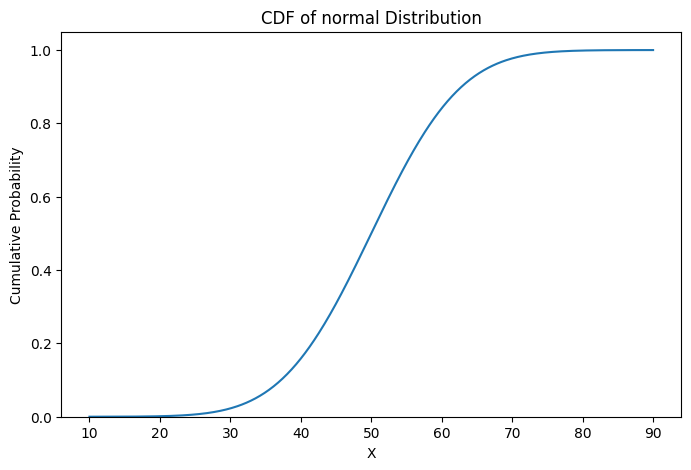

In [25]:
cdf=stats.norm.cdf(x,loc=50,scale=10)
plt.plot(x,cdf)
plt.xlabel("X")
plt.ylabel("Cumulative Probability")
plt.title("CDF of normal Distribution")

plt.ylim(0,1.05)
plt.show()

## Density Estimation

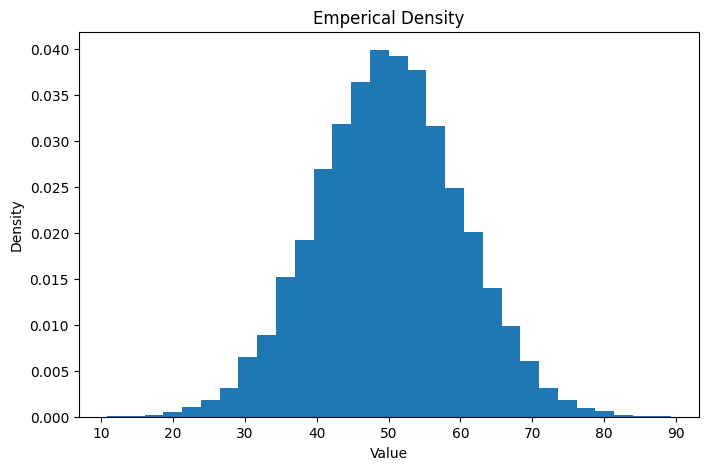

In [26]:
plt.hist(data,bins=30,density=True)
plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Emperical Density")
plt.show()

## Parametric Density Estimation

In [27]:
# Calculate mean and standard deviation
mean = np.mean(data)
std = np.std(data)

print("Mean:", mean)
print("Standard deviation:", std)

Mean: 49.97864016631574
Standard deviation: 10.034122061299875


In [28]:
# calculate PDF
x = np.linspace(data.min(), data.max(), 500)

pdf = stats.norm.pdf(
    x,
    loc=mean,
    scale=std
)

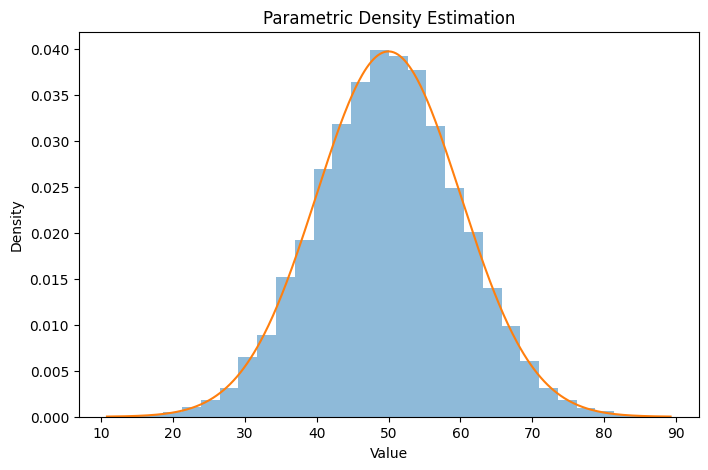

In [29]:
# calculate parametric Estimation
plt.hist(data, bins=30, density=True, alpha=0.5)

plt.plot(x, pdf)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Parametric Density Estimation")

plt.show()

## Non-Parametric Density Estimation — KDE

In [30]:
from scipy.stats import gaussian_kde

kde = gaussian_kde(data)

In [31]:
# generate density estimates
x = np.linspace(data.min(), data.max(), 500)

kde_values = kde(x)

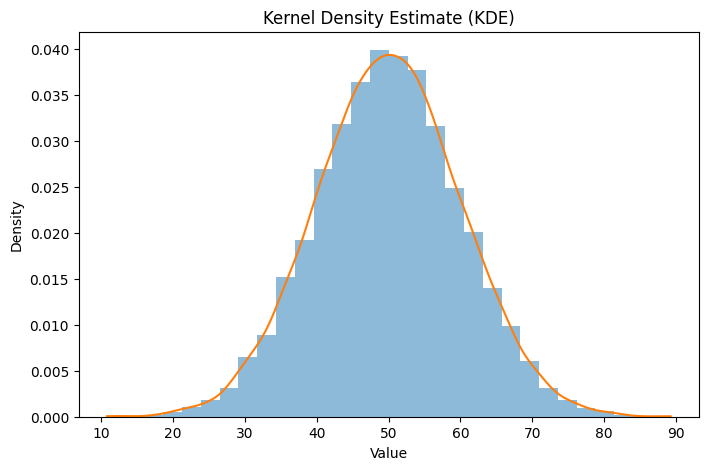

In [32]:
plt.hist(data, bins=30, density=True, alpha=0.5)

plt.plot(x, kde_values)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("Kernel Density Estimate (KDE)")

plt.show()

## KDE with Seaborn

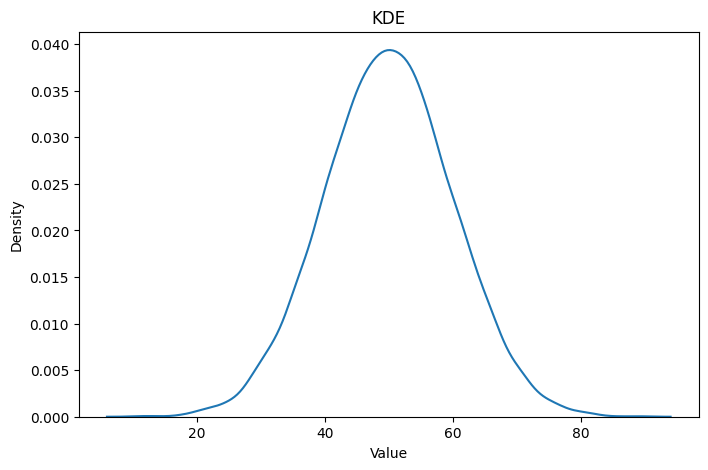

In [36]:
import seaborn as sns

sns.kdeplot(data)

plt.xlabel("Value")
plt.ylabel("Density")
plt.title("KDE")

plt.show()

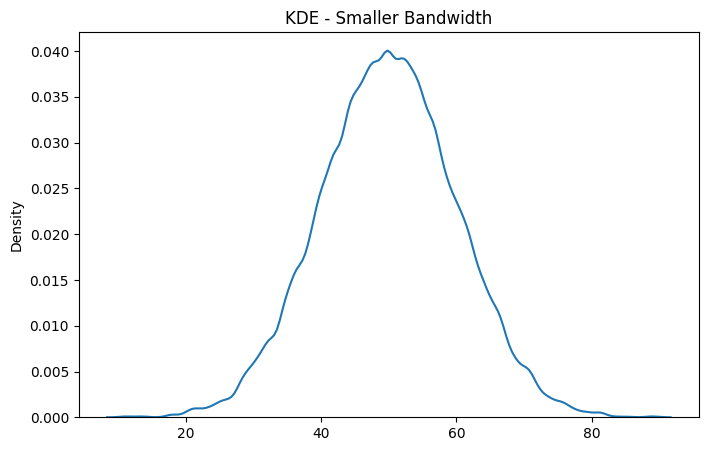

In [37]:
sns.kdeplot(data, bw_adjust=0.5)
plt.title("KDE - Smaller Bandwidth")
plt.show()

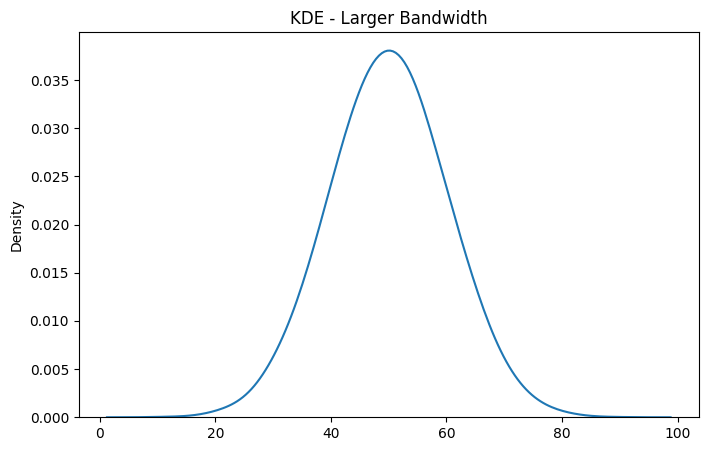

In [38]:
sns.kdeplot(data, bw_adjust=2)
plt.title("KDE - Larger Bandwidth")
plt.show()

In [ ]:
# Note:
# Smaller bandwidth → more wiggly
# Larger bandwidth → smoother